# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Muhammad Himbar Buana
- Username Dicoding: himbarbuana
- Fokus proyek: prediksi biner status akhir siswa `Dropout` vs `Graduate` untuk mendukung intervensi retensi.

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from model_utils import IQRClipper

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

BASE_DIR = Path('.').resolve()
DATA_PATH = BASE_DIR / 'data' / 'data.csv'
MODEL_DIR = BASE_DIR / 'model'
MODEL_DIR.mkdir(exist_ok=True)

print('Notebook siap dijalankan.')
print('Sumber data: data/data.csv')

Notebook siap dijalankan.
Sumber data: data/data.csv


### Menyiapkan data yang akan digunakan
Pada tahap ini dataset dimuat terlebih dahulu, lalu difilter agar analisis, dashboard, dan pemodelan hanya menggunakan siswa dengan status akhir `Dropout` dan `Graduate`. Status `Enrolled` dikeluarkan agar selaras dengan tujuan proyek dan catatan reviewer.

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8-sig').rename(columns={'Status': 'Target'})
df = df_raw[df_raw['Target'].isin(['Dropout', 'Graduate'])].copy()

print('Dimensi dataset awal:', df_raw.shape)
print('Dimensi dataset final (Dropout + Graduate):', df.shape)
print('Jumlah data Enrolled yang dikeluarkan:', int((df_raw['Target'] == 'Enrolled').sum()))
print('\nLima baris pertama data final:')
display(df.head())

print('\nDistribusi target pada data final:')
display(df['Target'].value_counts().to_frame('count'))

print('\nTipe data:')
display(df.dtypes.to_frame('dtype').T)

missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = int(df.duplicated().sum())
print(f'Jumlah data duplikat pada data final: {duplicate_count}')
print(f'Total missing value pada data final: {int(missing_summary.sum())}')


Dimensi dataset awal: (4424, 37)
Dimensi dataset final (Dropout + Graduate): (3630, 37)
Jumlah data Enrolled yang dikeluarkan: 794

Lima baris pertama data final:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Distribusi target pada data final:


,count
Target,
Graduate,2209
Dropout,1421



Tipe data:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
dtype,int64,int64,int64,int64,int64,int64,float64,int64,int64,int64,...,int64,int64,int64,int64,float64,int64,float64,float64,float64,str


Jumlah data duplikat pada data final: 0
Total missing value pada data final: 0


## Data Understanding
Analisis difokuskan pada pola yang membedakan siswa `Dropout` dan `Graduate`. Pendekatan ini membantu institusi memetakan faktor risiko yang benar-benar relevan untuk intervensi retensi.

### EDA Univariate dan Kategorikal

Distribusi univariate fitur kategorikal terpilih:


Tuition_fees_up_to_date,1,0
count,3144,486


Gender,0,1
count,2381,1249


Daytime_evening_attendance,1,0
count,3222,408


Scholarship_holder,0,1
count,2661,969


Debtor,0,1
count,3217,413


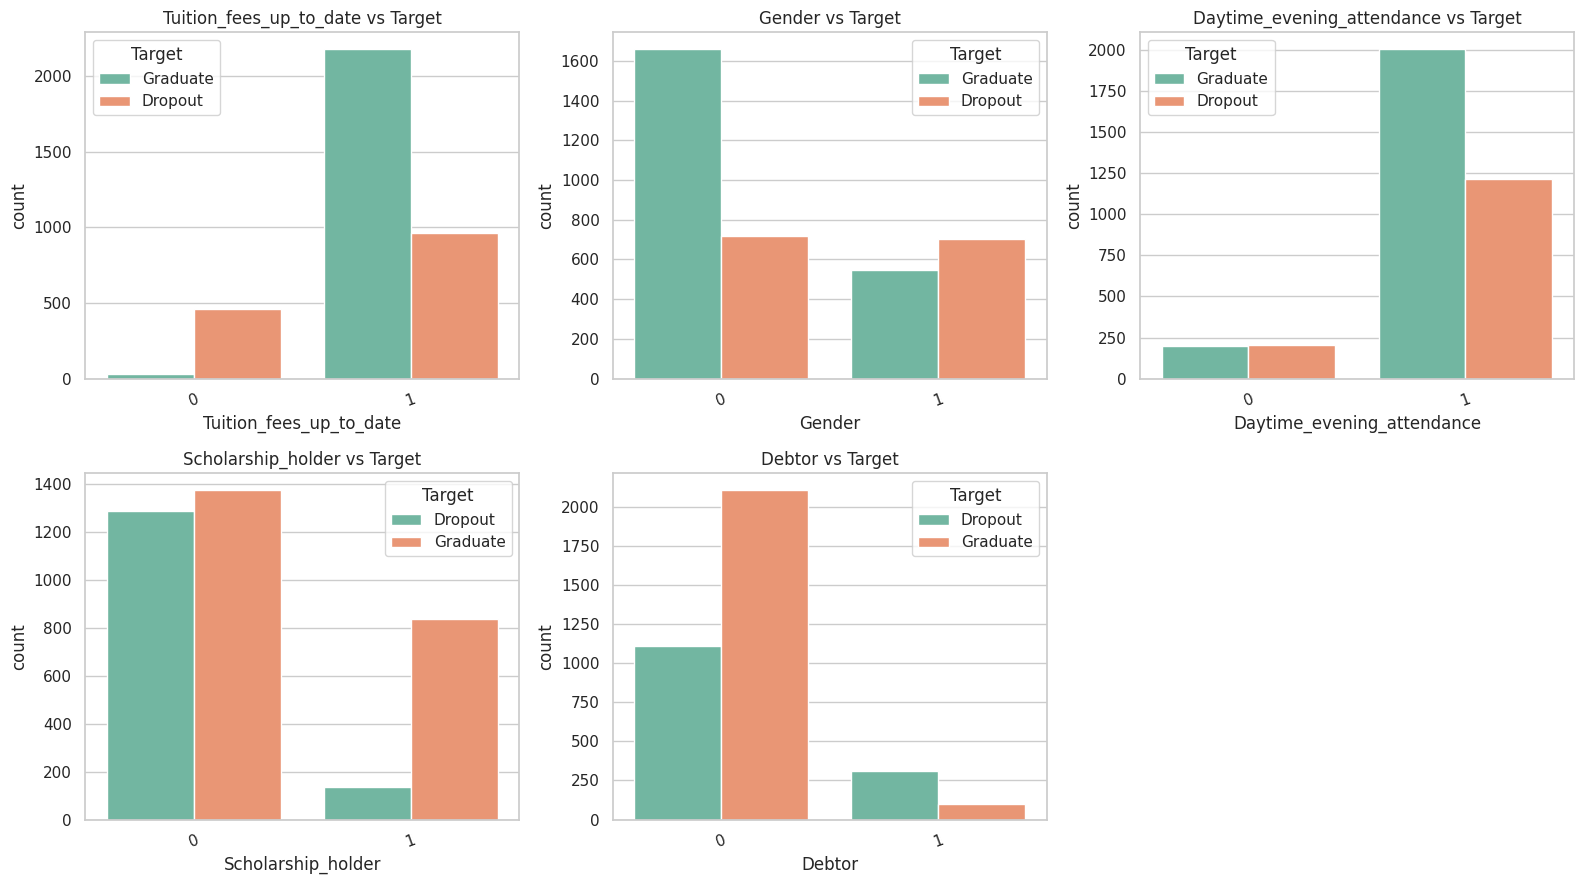

Ringkasan numerik per status siswa:


Age_at_enrollment        Admission_grade         \
                      mean median            mean median   
Target                                                     
Dropout              26.07   23.0          124.96  123.6   
Graduate             21.78   19.0          128.79  127.4   

         Curricular_units_1st_sem_approved         \
                                      mean median   
Target                                              
Dropout                               2.55    2.0   
Graduate                              6.23    6.0   

         Curricular_units_2nd_sem_approved         \
                                      mean median   
Target                                              
Dropout                               1.94    0.0   
Graduate                              6.18    6.0   

         Curricular_units_2nd_sem_grade         
                                   mean median  
Target                                          
Dropout                             5.9    0.0  
Graduate                           12.7   13.0

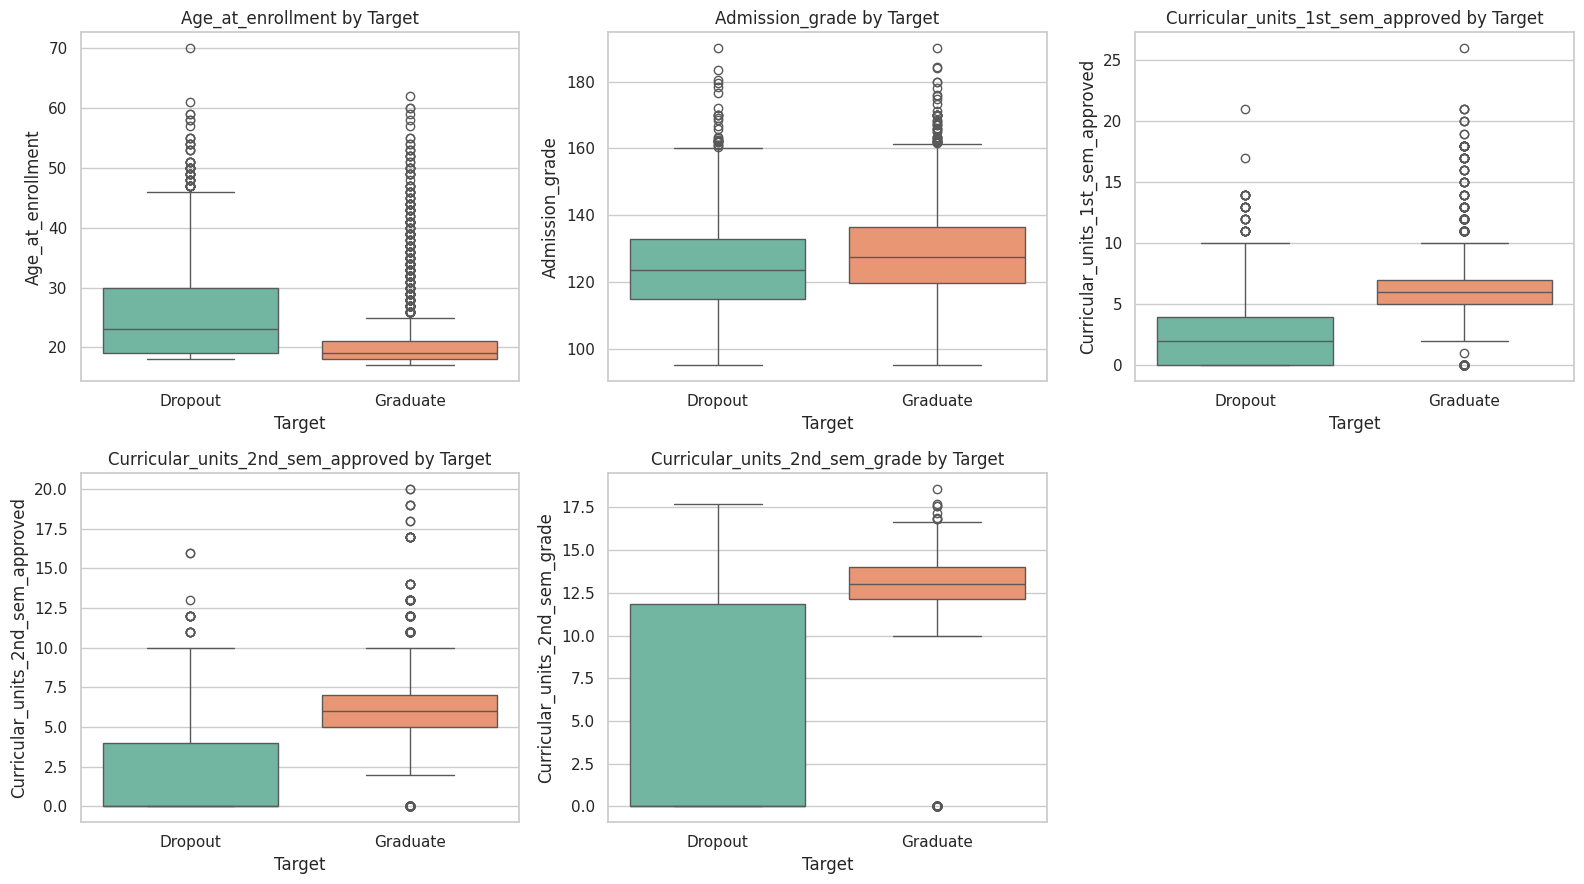

In [3]:
categorical_focus = ['Tuition_fees_up_to_date', 'Gender', 'Daytime_evening_attendance', 'Scholarship_holder', 'Debtor']
numeric_focus = ['Age_at_enrollment', 'Admission_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']

print('Distribusi univariate fitur kategorikal terpilih:')
for col in categorical_focus:
    display(df[col].value_counts(dropna=False).to_frame('count').T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes[:5], categorical_focus):
    sns.countplot(data=df, x=col, hue='Target', ax=ax)
    ax.set_title(f'{col} vs Target')
    ax.tick_params(axis='x', rotation=20)
for ax in axes[5:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

numeric_summary = df.groupby('Target')[numeric_focus].agg(['mean', 'median']).round(2)
print('Ringkasan numerik per status siswa:')
display(numeric_summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes[:5], numeric_focus):
    sns.boxplot(data=df, x='Target', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Target')
for ax in axes[5:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### EDA Multivariat dan Dasar Pemilihan Fitur
Tahap ini digunakan untuk melihat interaksi antar variabel yang paling relevan dengan risiko dropout serta memastikan fitur yang dipilih untuk modeling benar-benar didukung oleh hasil analisis.

Jumlah dan proporsi status berdasarkan status pembayaran biaya kuliah:


Target,Dropout,Graduate
Tuition_fees_up_to_date,,
0,457,29
1,964,2180


Target,Dropout,Graduate
Tuition_fees_up_to_date,,
0,0.940,0.060
1,0.307,0.693


Dropout rate berdasarkan kelompok usia:


,dropout_rate
age_band,
< 20,0.261
20-24,0.457
25-29,0.702
30+,0.614


Program studi dengan jumlah dropout tertinggi:


,dropout_count
Course,
9991,136
9147,134
9500,118
9773,101
9254,96
9670,95
9119,92
9085,90
9003,86


Rata-rata approved units per status akhir:


,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved
Target,,
Dropout,2.55,1.94
Graduate,6.23,6.18


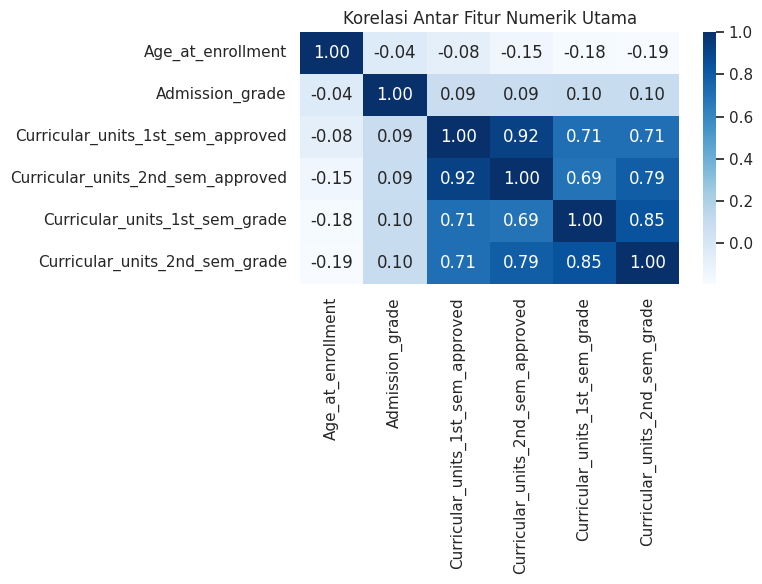

Insight utama hasil EDA:
- Siswa dengan pembayaran biaya kuliah tidak mutakhir memiliki proporsi dropout yang sangat dominan dibanding kelompok yang up to date.
- Approved units semester pertama dan kedua menunjukkan pemisahan yang jelas antara kelompok Dropout dan Graduate.
- Risiko dropout meningkat pada kelompok usia masuk yang lebih tinggi, terutama di atas 25 tahun.
- Program studi tertentu menampung konsentrasi kasus dropout lebih tinggi sehingga layak diprioritaskan pada intervensi.


In [4]:
tuition_target_count = pd.crosstab(df['Tuition_fees_up_to_date'], df['Target'])
tuition_target_rate = pd.crosstab(df['Tuition_fees_up_to_date'], df['Target'], normalize='index').round(3)

age_band_df = df.copy()
age_band_df['age_band'] = pd.cut(age_band_df['Age_at_enrollment'], bins=[0, 20, 25, 30, 100], labels=['< 20', '20-24', '25-29', '30+'])
age_dropout = age_band_df.groupby('age_band', observed=False)['Target'].apply(lambda s: (s == 'Dropout').mean()).round(3).to_frame('dropout_rate')
course_dropout = df[df['Target'] == 'Dropout']['Course'].value_counts().head(10).to_frame('dropout_count')
approved_summary = df.groupby('Target')[['Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved']].mean().round(2)

print('Jumlah dan proporsi status berdasarkan status pembayaran biaya kuliah:')
display(tuition_target_count)
display(tuition_target_rate)

print('Dropout rate berdasarkan kelompok usia:')
display(age_dropout)

print('Program studi dengan jumlah dropout tertinggi:')
display(course_dropout)

print('Rata-rata approved units per status akhir:')
display(approved_summary)

corr_cols = ['Age_at_enrollment', 'Admission_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Korelasi Antar Fitur Numerik Utama')
plt.tight_layout()
plt.show()

print('Insight utama hasil EDA:')
print('- Siswa dengan pembayaran biaya kuliah tidak mutakhir memiliki proporsi dropout yang sangat dominan dibanding kelompok yang up to date.')
print('- Approved units semester pertama dan kedua menunjukkan pemisahan yang jelas antara kelompok Dropout dan Graduate.')
print('- Risiko dropout meningkat pada kelompok usia masuk yang lebih tinggi, terutama di atas 25 tahun.')
print('- Program studi tertentu menampung konsentrasi kasus dropout lebih tinggi sehingga layak diprioritaskan pada intervensi.')

Temuan EDA di atas menjadi dasar pemilihan fitur pada tahap berikutnya. Fitur seperti `Tuition_fees_up_to_date`, `Age_at_enrollment`, `Course`, `Curricular_units_1st_sem_approved`, dan `Curricular_units_2nd_sem_approved` dipertahankan karena secara visual maupun numerik menunjukkan pemisahan yang kuat antara kelompok `Dropout` dan `Graduate`.

## Data Preparation / Preprocessing

In [5]:
selected_features = [
    'Marital_status', 'Application_mode', 'Application_order', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade',
    'Admission_grade', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender',
    'Scholarship_holder', 'Age_at_enrollment', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP'
]

categorical_features = [
    'Marital_status', 'Application_mode', 'Course', 'Daytime_evening_attendance',
    'Previous_qualification', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date',
    'Gender', 'Scholarship_holder'
]

numeric_features = [col for col in selected_features if col not in categorical_features]

X = df[selected_features].copy()
y = df['Target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

outlier_before = {}
for col in numeric_features:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_before[col] = int(((X_train[col] < lower) | (X_train[col] > upper)).sum())

clipper = IQRClipper().fit(X_train[numeric_features])
X_train_clipped = pd.DataFrame(clipper.transform(X_train[numeric_features]), columns=numeric_features, index=X_train.index)

outlier_after = {}
for col in numeric_features:
    q1 = X_train_clipped[col].quantile(0.25)
    q3 = X_train_clipped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_after[col] = int(((X_train_clipped[col] < lower) | (X_train_clipped[col] > upper)).sum())

outlier_comparison = pd.DataFrame({'before_handling': outlier_before, 'after_handling': outlier_after}).sort_values('before_handling', ascending=False)
print('Perbandingan jumlah outlier sebelum dan sesudah handling:')
display(outlier_comparison.head(10))

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clipper', IQRClipper()),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

print('Jumlah fitur terpilih:', len(selected_features))
print('Fitur kategorikal:', categorical_features)
print('Fitur numerik:', numeric_features)
print('Distribusi target train set:')
display(y_train.value_counts().to_frame('count'))

Perbandingan jumlah outlier sebelum dan sesudah handling:


,before_handling,after_handling
Curricular_units_2nd_sem_grade,649,0
Curricular_units_1st_sem_grade,523,0
Application_order,375,0
Curricular_units_1st_sem_enrolled,295,0
Curricular_units_2nd_sem_enrolled,261,0
Age_at_enrollment,251,0
Curricular_units_1st_sem_approved,134,0
Previous_qualification_grade,111,0
Admission_grade,57,0
Curricular_units_2nd_sem_approved,35,0


Jumlah fitur terpilih: 23
Fitur kategorikal: ['Marital_status', 'Application_mode', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder']
Fitur numerik: ['Application_order', 'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP']
Distribusi target train set:


,count
Target,
Graduate,1767
Dropout,1137


## Modeling

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

results = {}
best_model_name = None
best_pipeline = None
best_f1 = -1

for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'accuracy': round(float(accuracy), 4),
        'precision_weighted': round(float(precision), 4),
        'recall_weighted': round(float(recall), 4),
        'f1_weighted': round(float(f1), 4),
    }

    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipeline = pipeline

results_df = pd.DataFrame(results).T.sort_values('f1_weighted', ascending=False)
print('Perbandingan performa model:')
display(results_df)

joblib.dump(best_pipeline, MODEL_DIR / 'student_status_pipeline.joblib')
print(f'Model terbaik: {best_model_name}')
print('Artefak model telah disimpan ke folder model.')

Perbandingan performa model:


,accuracy,precision_weighted,recall_weighted,f1_weighted
Logistic Regression,0.9160,0.9176,0.9160,0.9150
Gradient Boosting,0.9132,0.9151,0.9132,0.9121
Random Forest,0.9105,0.9144,0.9105,0.9089


Model terbaik: Logistic Regression
Artefak model telah disimpan ke folder model.


## Evaluation

Classification report:


,precision,recall,f1-score,support
Dropout,0.940711,0.838028,0.886406,284.000000
Graduate,0.902748,0.966063,0.933333,442.000000
accuracy,0.915978,0.915978,0.915978,0.915978
macro avg,0.921730,0.902046,0.909870,726.000000
weighted avg,0.917599,0.915978,0.914976,726.000000


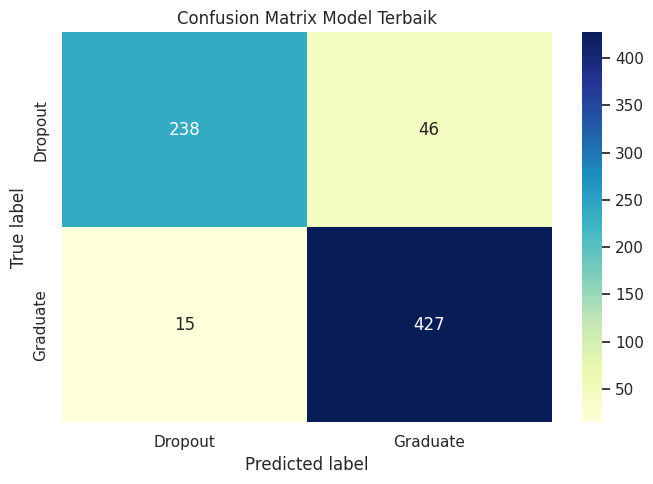

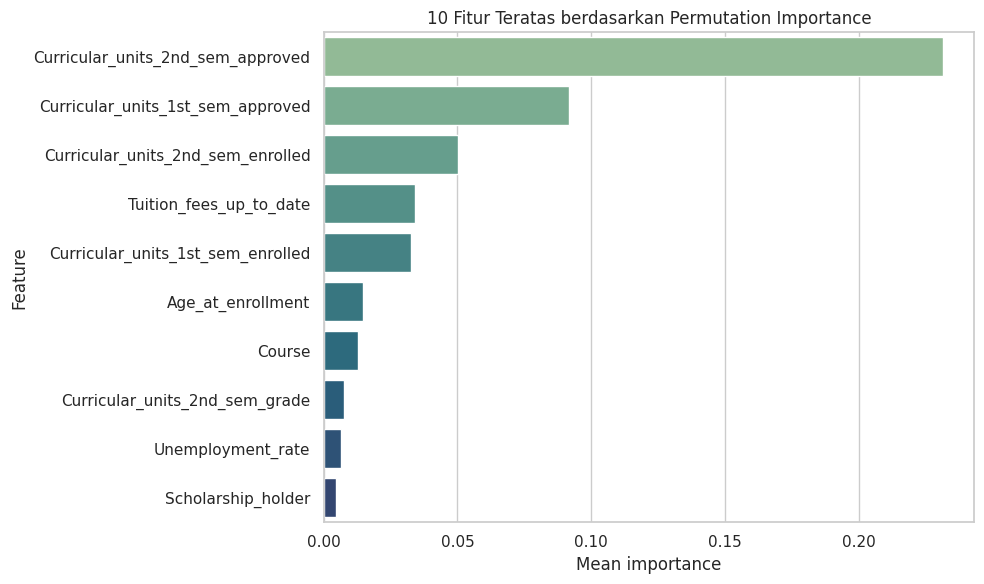

Lima faktor paling berpengaruh:


,feature,importance_mean,importance_std
18,Curricular_units_2nd_sem_approved,0.231606,0.015710
15,Curricular_units_1st_sem_approved,0.091585,0.005588
17,Curricular_units_2nd_sem_enrolled,0.050379,0.006307
10,Tuition_fees_up_to_date,0.034190,0.003465
14,Curricular_units_1st_sem_enrolled,0.032668,0.004045


Kesimpulan evaluasi:
- Model terbaik: Logistic Regression
- Accuracy: 0.916
- Weighted F1-score: 0.915


In [7]:
best_pred = best_pipeline.predict(X_test)
report = classification_report(y_test, best_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T

cm = confusion_matrix(y_test, best_pred, labels=best_pipeline.classes_)
perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_weighted', n_jobs=-1)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

summary = {
    'row_count': int(df.shape[0]),
    'column_count': int(df.shape[1]),
    'raw_row_count': int(df_raw.shape[0]),
    'duplicate_count': int(df.duplicated().sum()),
    'missing_total': int(df.isna().sum().sum()),
    'target_distribution': {k: int(v) for k, v in df['Target'].value_counts().to_dict().items()},
    'selected_features': selected_features,
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'model_results': results,
    'best_model': best_model_name,
    'best_model_metrics': results[best_model_name],
    'classification_report': report,
    'confusion_matrix': cm.tolist(),
    'class_labels': list(best_pipeline.classes_),
    'feature_importance': feature_importance.to_dict(orient='records'),
    'sample_defaults': {col: (float(X[col].median()) if col in numeric_features else str(X[col].mode(dropna=True).iloc[0])) for col in selected_features},
}
(MODEL_DIR / 'metrics_summary.json').write_text(json.dumps(summary, indent=2))
feature_importance.to_csv(MODEL_DIR / 'feature_importance.csv', index=False)

print('Classification report:')
display(report_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
plt.title('Confusion Matrix Model Terbaik')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance_mean', y='feature', palette='crest')
plt.title('10 Fitur Teratas berdasarkan Permutation Importance')
plt.xlabel('Mean importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Lima faktor paling berpengaruh:')
display(feature_importance.head(5))

print('Kesimpulan evaluasi:')
print(f"- Model terbaik: {best_model_name}")
print(f"- Accuracy: {results[best_model_name]['accuracy']}")
print(f"- Weighted F1-score: {results[best_model_name]['f1_weighted']}")

### Evaluasi Kelompok

Dropout rate berdasarkan gender:


,dropout_rate
Gender,
Female,0.302394
Male,0.561249


Dropout rate berdasarkan status pembayaran biaya kuliah:


,dropout_rate
Tuition_fees_up_to_date,
Not up to date,0.940329
Up to date,0.306616


Dropout rate berdasarkan kelompok usia:


,dropout_rate
age_band,
25-29,0.702454
30+,0.614187
20-24,0.456656
< 20,0.260577


Top 5 program studi dengan jumlah dropout tertinggi:


,dropout_count
Course,
9991,136
9147,134
9500,118
9773,101
9254,96


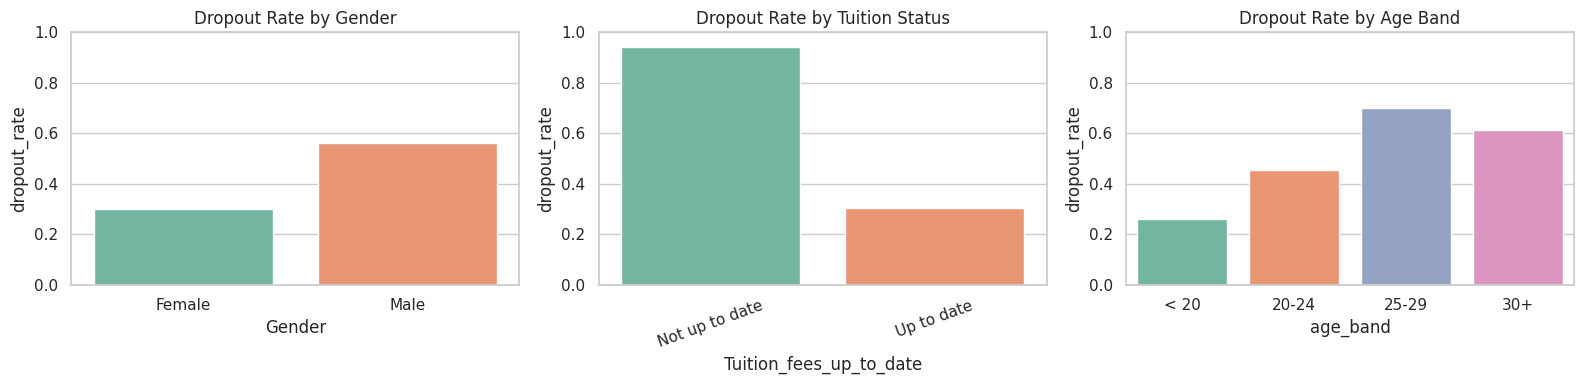

In [8]:
group_df = df.copy()
group_df['age_band'] = pd.cut(group_df['Age_at_enrollment'], bins=[0, 20, 25, 30, 100], labels=['< 20', '20-24', '25-29', '30+'])
group_df['dropout_flag'] = group_df['Target'].eq('Dropout').astype(int)

bias_by_gender = group_df.groupby('Gender')['dropout_flag'].mean().rename({0: 'Female', 1: 'Male'}).to_frame('dropout_rate')
bias_by_tuition = group_df.groupby('Tuition_fees_up_to_date')['dropout_flag'].mean().rename({0: 'Not up to date', 1: 'Up to date'}).to_frame('dropout_rate')
dropout_by_age = group_df.groupby('age_band', observed=False)['dropout_flag'].mean().sort_values(ascending=False).to_frame('dropout_rate')
dropout_courses = group_df[group_df['Target'] == 'Dropout']['Course'].value_counts().head(5).to_frame('dropout_count')

print('Dropout rate berdasarkan gender:')
display(bias_by_gender)
print('Dropout rate berdasarkan status pembayaran biaya kuliah:')
display(bias_by_tuition)
print('Dropout rate berdasarkan kelompok usia:')
display(dropout_by_age)
print('Top 5 program studi dengan jumlah dropout tertinggi:')
display(dropout_courses)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=bias_by_gender.reset_index(), x='Gender', y='dropout_rate', ax=axes[0], palette='Set2')
axes[0].set_title('Dropout Rate by Gender')
axes[0].set_ylim(0, 1)

sns.barplot(data=bias_by_tuition.reset_index(), x='Tuition_fees_up_to_date', y='dropout_rate', ax=axes[1], palette='Set2')
axes[1].set_title('Dropout Rate by Tuition Status')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=dropout_by_age.reset_index(), x='age_band', y='dropout_rate', ax=axes[2], palette='Set2')
axes[2].set_title('Dropout Rate by Age Band')
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Simulasi What-if

,approved_units_2nd_sem,predicted_status,dropout_probability,tuition_status
0,0,Dropout,0.8547,NaN
1,2,Dropout,0.5249,NaN
2,4,Graduate,0.1719,NaN
3,6,Graduate,0.0375,NaN
4,8,Graduate,0.0073,NaN
5,baseline,Dropout,0.5256,0.0
6,baseline,Graduate,0.0825,1.0


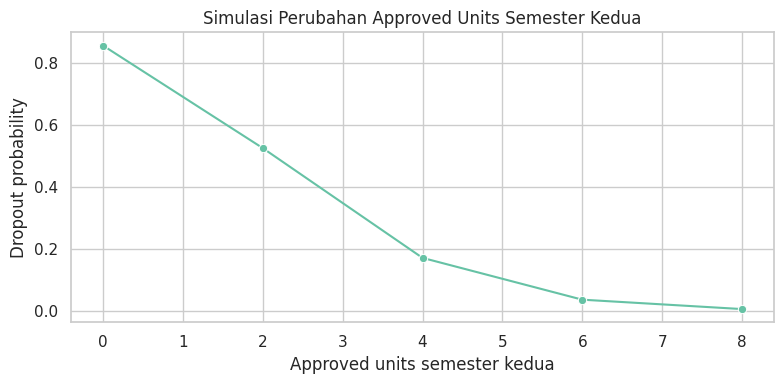

Interpretasi singkat: semakin sedikit mata kuliah semester kedua yang disetujui, semakin tinggi probabilitas dropout yang diprediksi model.


In [9]:
base_input = {col: (float(df[col].median()) if col in numeric_features else int(df[col].mode().iloc[0])) for col in selected_features}
scenario_base = pd.DataFrame([base_input])[selected_features]
classes = list(best_pipeline.classes_)
dropout_idx = classes.index('Dropout')

def predict_dropout_probability(frame):
    return round(float(best_pipeline.predict_proba(frame)[0][dropout_idx]), 4)

scenario_rows = []
for approved_units in [0, 2, 4, 6, 8]:
    frame = scenario_base.copy()
    frame['Curricular_units_2nd_sem_approved'] = approved_units
    scenario_rows.append({
        'approved_units_2nd_sem': approved_units,
        'predicted_status': best_pipeline.predict(frame)[0],
        'dropout_probability': predict_dropout_probability(frame),
    })

for tuition_status in [0, 1]:
    frame = scenario_base.copy()
    frame['Tuition_fees_up_to_date'] = tuition_status
    scenario_rows.append({
        'approved_units_2nd_sem': 'baseline',
        'predicted_status': best_pipeline.predict(frame)[0],
        'dropout_probability': predict_dropout_probability(frame),
        'tuition_status': tuition_status,
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

plot_df = scenario_df[scenario_df['approved_units_2nd_sem'] != 'baseline'].copy()
plot_df['approved_units_2nd_sem'] = plot_df['approved_units_2nd_sem'].astype(int)
plt.figure(figsize=(8, 4))
sns.lineplot(data=plot_df, x='approved_units_2nd_sem', y='dropout_probability', marker='o')
plt.title('Simulasi Perubahan Approved Units Semester Kedua')
plt.xlabel('Approved units semester kedua')
plt.ylabel('Dropout probability')
plt.tight_layout()
plt.show()

print('Interpretasi singkat: semakin sedikit mata kuliah semester kedua yang disetujui, semakin tinggi probabilitas dropout yang diprediksi model.')